In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn torch transformers datasets accelerate


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

c:\Users\Vicky\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


***
Load Dataset 

In [3]:
train = pd.read_csv("Dataset/train.csv", sep=";")
test = pd.read_csv("Dataset/test.csv", sep=";")

train.head()

,text,label
0,dark agenda behind globalism open border altma...,0
1,america poor still get shaft sami jamil jadall...,0
2,number accuser grow former miss finland accuse...,0
3,heroic prego advertisement replaces refresh we...,0
4,russia syria debbie reynolds thursday even bri...,1


In [4]:
test.head()

,text,label
0,trump promise new deal black america trump pro...,0
1,foundation tie bedevil hillary clinton preside...,1
2,number week long russia end oil dependence rbt...,0
3,codesod rule ten remy porter remy escape enter...,0
4,switch chip know anymore home scitech switch c...,0


***
EDA Process

In [5]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (16646, 2)
Test shape: (4035, 2)


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16646 entries, 0 to 16645
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16646 non-null  object
 1   label   16646 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 260.2+ KB


In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4035 entries, 0 to 4034
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    4035 non-null   object
 1   label   4035 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 63.2+ KB


In [8]:
train.isnull().sum()

text     0
label    0
dtype: int64

In [9]:
test.isnull().sum()

text     0
label    0
dtype: int64

In [10]:
print("Train duplicate rows:", train.duplicated().sum())
print("Test duplicate rows:", test.duplicated().sum())

Train duplicate rows: 171
Test duplicate rows: 4


In [11]:
train = train.drop_duplicates()
test = test.drop_duplicates()

print("Train shape after duplicate removal:", train.shape)
print("Test shape after duplicate removal:", test.shape)

Train shape after duplicate removal: (16475, 2)
Test shape after duplicate removal: (4031, 2)


In [12]:
train["label"].value_counts()

label
1    8323
0    8152
Name: count, dtype: int64

In [13]:
test["label"].value_counts()

label
1    2056
0    1975
Name: count, dtype: int64

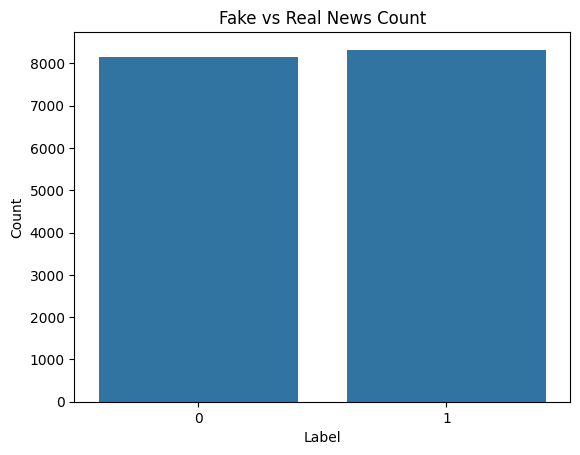

In [14]:
sns.countplot(x="label", data=train)
plt.title("Fake vs Real News Count")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [15]:
train["word_count"] = train["text"].apply(lambda x: len(str(x).split()))
test["word_count"] = test["text"].apply(lambda x: len(str(x).split()))

train["word_count"].describe()

count    16475.000000
mean       427.035448
std        443.635564
min          1.000000
25%        161.000000
50%        319.000000
75%        587.000000
max      10210.000000
Name: word_count, dtype: float64

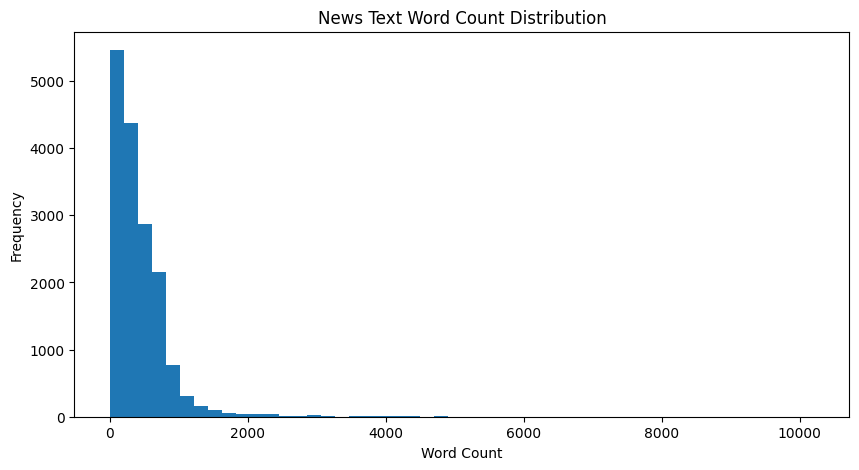

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(train["word_count"], bins=50)
plt.title("News Text Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

***
DATA CLEANING

In [17]:
def clean_text(text):
    text = str(text)

    # remove links
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [18]:
train["clean_text"] = train["text"].apply(clean_text)
test["clean_text"] = test["text"].apply(clean_text)

train[["text", "clean_text", "label"]].head()

,text,clean_text,label
0,dark agenda behind globalism open border altma...,dark agenda behind globalism open border altma...,0
1,america poor still get shaft sami jamil jadall...,america poor still get shaft sami jamil jadall...,0
2,number accuser grow former miss finland accuse...,number accuser grow former miss finland accuse...,0
3,heroic prego advertisement replaces refresh we...,heroic prego advertisement replaces refresh we...,0
4,russia syria debbie reynolds thursday even bri...,russia syria debbie reynolds thursday even bri...,1


In [19]:
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

CUDA Available: False


***
Convert Pandas to Hugging Face Dataset

In [20]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train[["clean_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test[["clean_text", "label"]]
)

train_dataset

Dataset({
    features: ['clean_text', 'label', '__index_level_0__'],
    num_rows: 16475
})

***
Load DistilBERT Tokenizer

In [21]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully")

Tokenizer loaded successfully


***
Tokenization Function

In [22]:
def tokenize_function(batch):
    return tokenizer(
        batch["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [23]:
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

Map: 100%|██████████| 4031/4031 [00:02<00:00, 1676.70 examples/s]


In [24]:
train_tokenized = train_tokenized.rename_column(
    "label",
    "labels"
)

test_tokenized = test_tokenized.rename_column(
    "label",
    "labels"
)

In [25]:
train_tokenized[0]

{'clean_text': 'dark agenda behind globalism open border altmarket brandon smith people unfamiliar liberty movement stumble onto undeniable fact conspiracy globalism tend look easy answer understand exist people today condition perceive event misinterpret standpoint occam razor wrongly assume simple explanation probably right one fact occam razor state instead summarize state simple explanation give evidence hand probably right explanation well know document decade push globalism deliberate focus effort part select elite international financier central banker political leader numerous member exclusive think tank often openly admit goal total globalization publication perhaps believe uneducated commoner would never read anyway carroll quigley mentor bill clinton member council foreign relation often quote open admission general scheme power financial capitalism farreaching aim nothing less create world system financial control private hand able dominate political system country economy 

***
SET FORMAT

In [26]:
train_tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [27]:
train_tokenized[0]

{'labels': tensor(0),
 'input_ids': tensor([  101,  2601, 11376,  2369,  3795,  2964,  2330,  3675, 12456, 20285,
          8825,  3044,  2111, 16261,  7044,  2929, 21811,  3031,  6151, 19825,
          3468,  2755,  9714,  3795,  2964,  7166,  2298,  3733,  3437,  3305,
          4839,  2111,  2651,  4650, 23084,  2724, 28616, 18447,  2121, 28139,
          2102,  3233,  8400,  1051, 16665,  2213, 15082, 29116,  7868,  3722,
          7526,  2763,  2157,  2028,  2755,  1051, 16665,  2213, 15082,  2110,
          2612,  7680,  7849,  4697,  2110,  3722,  7526,  2507,  3350,  2192,
          2763,  2157,  7526,  2092,  2113,  6254,  5476,  5245,  3795,  2964,
         15063,  3579,  3947,  2112,  7276,  7069,  2248, 10346,  2319, 19562,
          2430, 13448,  2576,  3003,  3365,  2266,  7262,  2228,  4951,  2411,
         10132,  6449,  3125,  2561, 24370,  4772,  3383,  2903, 16655,  8566,
         12921,  2691,  2121,  2052,  2196,  3191,  4312, 10767, 21864, 22971,
         10779,  

***
LOAD MODEL - (DistilBERT Model)

In [28]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("DistilBERT model loaded successfully")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 206.96it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully


***
Metrics Function

In [29]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    predictions = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

***
Training Process

In [30]:
# Ensure required packages are installed (may take a moment).
!pip install 'accelerate>=1.1.0' transformers[torch] -q


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: "'accelerate": Expected package name at the start of dependency specifier
    'accelerate
    ^


In [31]:
from transformers import TrainingArguments
import os
# Use the new env var to avoid the deprecated `logging_dir` argument
os.environ['TENSORBOARD_LOGGING_DIR'] = './logs'

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    report_to="none",
)

In [32]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,

    compute_metrics=compute_metrics
)

print("Trainer created")

Trainer created


In [33]:
trainer.train()

c:\Users\Vicky\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.087011,0.105557,0.972711,0.965550,0.981518,0.973468
2,0.045315,0.102223,0.979658,0.984298,0.975681,0.979971


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.73it/s]
c:\Users\Vicky\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.15it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4120, training_loss=0.0978654380019718, metrics={'train_runtime': 10485.7844, 'train_samples_per_second': 3.142, 'train_steps_per_second': 0.393, 'total_flos': 1091200196428800.0, 'train_loss': 0.0978654380019718, 'epoch': 2.0})

***
Evaluate Model

In [34]:
eval_results = trainer.evaluate()

print(eval_results)

c:\Users\Vicky\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.10222333669662476, 'eval_accuracy': 0.9796576531877946, 'eval_precision': 0.9842983316977428, 'eval_recall': 0.97568093385214, 'eval_f1': 0.979970688812897, 'eval_runtime': 207.9488, 'eval_samples_per_second': 19.385, 'eval_steps_per_second': 2.424, 'epoch': 2.0}


***
Classification Report

In [35]:
predictions = trainer.predict(test_tokenized)

import numpy as np
from sklearn.metrics import classification_report

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred))

c:\Users\Vicky\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1975
           1       0.98      0.98      0.98      2056

    accuracy                           0.98      4031
   macro avg       0.98      0.98      0.98      4031
weighted avg       0.98      0.98      0.98      4031



***
Confusion Matrix

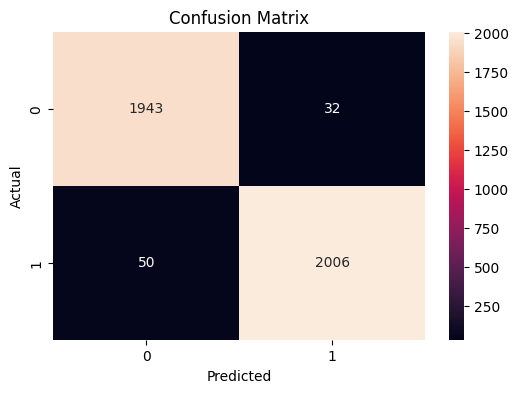

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

***
Save Model

In [37]:
model.save_pretrained("distilbert_fake_news_model")
tokenizer.save_pretrained("distilbert_fake_news_model")

print("Model saved successfully")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.89it/s]

Model saved successfully


***
Prediction Function

In [88]:
import torch

def predict_news(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()

    return "Real News" if prediction == 1 else "Fake News"

In [91]:
def predict_news(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()

    return "Real News" if prediction == 0 else "Fake News"

In [92]:
predict_news("""
India successfully launched a new satellite from the Satish Dhawan Space Centre in Sriharikota on Tuesday. Scientists confirmed the mission achieved all planned objectives and the satellite was successfully placed into orbit.
""")

'Real News'

In [93]:
import torch
import torch.nn.functional as F

text = """
The Indian Space Research Organisation (ISRO) successfully launched a new weather monitoring satellite from the Satish Dhawan Space Centre on Wednesday. According to ISRO officials, the satellite will improve weather forecasting, disaster management, and climate monitoring across the country. Scientists stated that the mission achieved all planned objectives and the satellite was successfully placed into its intended orbit.
"""

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

with torch.no_grad():
    outputs = model(**inputs)

probs = F.softmax(outputs.logits, dim=1)

print("Real Probability:", probs[0][0].item())
print("Fake Probability:", probs[0][1].item())

Real Probability: 0.2076117992401123
Fake Probability: 0.7923882007598877


In [94]:
def predict_news_with_confidence(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)
    
    real_prob = probs[0][0].item()
    fake_prob = probs[0][1].item()

    if abs(real_prob - fake_prob) < 0.20:
        return "Uncertain - Need fact checking", real_prob, fake_prob

    if real_prob > fake_prob:
        return "Real News", real_prob, fake_prob
    else:
        return "Fake News", real_prob, fake_prob

In [95]:
predict_news_with_confidence(text)

('Fake News', 0.2076117992401123, 0.7923882007598877)